# Transition-specific timing with `event_transition_interval`

This tutorial shows how to assign different timing distributions to different event transitions within a trial. The goal is to model tasks in which the gap between two events depends on which specific transition just happened. To be more precise, in a trial with events {A, B}, we want the gap between A and B to depend on whether the event immediately preceding B was A1 or A2. For this reason, one global rule for that gap is unsuited.

This is a within-trial effect: `event_transition_interval` only governs the gap between two events that belong to the same conceptual trial. It is distinct from `inter_trial_interval`, which governs the gap between one trial's last event and the next trial's first event, and it is not affected by `event_transition_interval`. A one-event-per-trial flat design has no within-trial gaps at all, so this tutorial builds its design from multi-event `trial_templates` instead — each trial has its own internal cue -> target -> response -> feedback sequence, giving `event_transition_interval` transitions to act on.

By the end, you will know how to:

1. define an `event_transition_interval` dictionary,
2. understand how `default` and `(previous_event, current_event)` keys interact,
3. inspect the resulting transition-specific timing in an optimized design.


In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import neurodesign

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110


## 1. When to use `event_transition_interval`

A single global rule is enough when every within-trial transition follows the same timing.  
When the gap between two events should depend on which transition just happened, `event_transition_interval` is meant to handle the creation of intervals between events (the Event Transition Interval, ETI).  
For example, in a trial consisting of a sequence of events: {cue -> target -> response -> feedback} sequence, the gap (ETI) separating the cue from the target might need to be short, while the gap separating the response from the feedback might need to be longer, even within the same trial.  
In this trial, we need to specify 3 ETIs.

`neurodesign-plus` encodes that logic with a dictionary:

- keys of the form `(previous_event, current_event)` define transition-specific timing, using the event categories declared in `trial_templates`,
- `"default"` is used for any within-trial transition not explicitly listed,
- the experiment still requires a separate `inter_trial_interval` rule for the gaps between trials — `event_transition_interval` does not replace it.

For this tutorial, we keep the trial template fixed (a single repeating template with exact sequence: {cue -> target -> response -> feedback}) so the only changing element is the within-trial timing (the ETIs).

Here, we specify only the ETIs for the transitions {cue -> target} and {response -> feedback}. The transition {target -> response} will use the default transition rule (here, a fixed transition of 1.5)

In [2]:
trial_templates = [
    {
        "template_id": "standard",
        "trial_type": "standard",
        "events": [
            {"category": "cue", "duration": 1},
            {"category": "target", "duration": 1},
            {"category": "response", "duration": 1},
            {"category": "feedback", "duration": 1},
        ],
    },
]
n_trials = 5

event_transition_rules = {
    ("cue", "target"): {"model": "uniform", "mean": 2.0, "min": 1, "max": 3},
    ("response", "feedback"): {"model": "exponential", "mean": 3.0, "min": 1, "max": 6},
    "default": {"model": "fixed", "value": 1.5},
}

categories = [event["category"] for event in trial_templates[0]["events"]]
within_trial_transitions = list(zip(categories[:-1], categories[1:]))
print("Within-trial transitions in each repeated trial:", within_trial_transitions)


Within-trial transitions in each repeated trial: [('cue', 'target'), ('target', 'response'), ('response', 'feedback')]


## 2. Build the experiment

The experiment below defines a single `trial_templates` entry with four events (`cue`, `target`, `response`, `feedback`) and repeats it for every conceptual trial via `trials=[{"template_id": "standard"}] * n_trials`. `event_transition_interval` then specifies the gap between consecutive events inside each trial: `(cue, target)` and `(response, feedback)` each get their own distribution, while `(target, response)` falls back to `default`.

**Key parameters:**

- `event_transition_interval` controls the within-trial event-to-event gaps.
- `inter_trial_interval` controls the separate gap between one trial's last event and the next trial's first event; it is unaffected by `event_transition_interval`.
- `trial_templates` + `trials` fix the trial structure and its repeated sequence, so timing is the only thing that varies across candidate designs — this isolates the `event_transition_interval` feature in a readable example.
- Each event lists its own `duration` inside `trial_templates`; a top-level `event_durations` argument is ignored in template mode.


In [3]:
exp = neurodesign.Experiment(
    TR=2,
    P=[0.25, 0.25, 0.25, 0.25],
    C=[[1, 0, -1, 0], [1, 0, 0, -1], [0, 1, -1, 0], [0, 1, 0, -1]],
    n_stimuli=4,
    rho=0.3,
    trial_start_interval=1,
    post_event_interval=0.5,
    inter_trial_interval={"model": "exponential", "min": 1, "max": 4, "mean": 2},
    event_transition_interval={"by_event_transition": event_transition_rules},
    trial_templates=trial_templates,
    trials=[{"template_id": "standard"}] * n_trials,
)

population = neurodesign.Optimisation(
    experiment=exp,
    R=[1, 0, 0],
    weights=[0, 0.5, 0.25, 0.25],  # order: Fe, Fd, Ff, Fc
    preruncycles=2,
    cycles=6,
    folder="./",
    seed=100,
)

population.optimise()

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\.venv\Lib\site-packages\rich\live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

First 9 within-trial transitions and their realized event_transition_interval:
(cue, target): 2.2
(target, response): 1.5
(response, feedback): 1.1
(cue, target): 1.2
(target, response): 1.5
(response, feedback): 1.4
(cue, target): 2.6
(target, response): 1.5
(response, feedback): 4.1
Fd (detection efficiency): 0.9558
Fe (estimation efficiency): 0.0000
Fc (confounding score): 0.2165
Ff (frequency-balance score): 1.0000


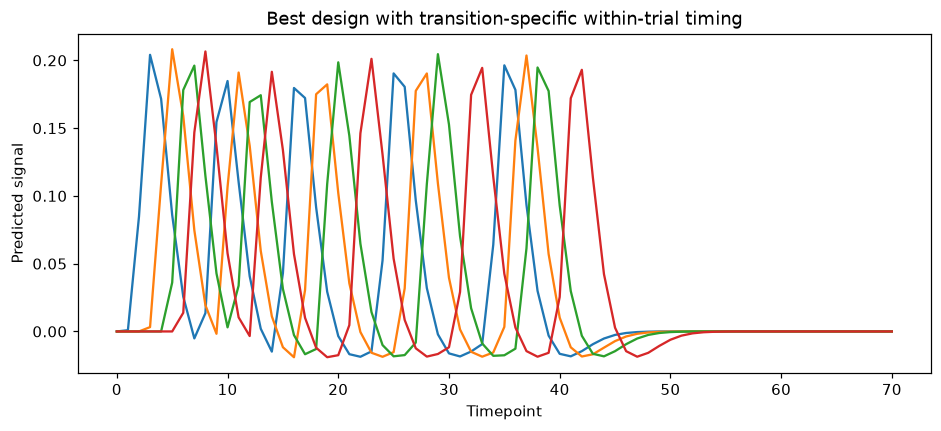

In [4]:
best_design = population.selected_design(0)
best_design.designmatrix()

from_idx = best_design.within_trial_transition_from_event_index
to_idx = best_design.within_trial_transition_to_event_index
categories = best_design.event_categories

print("First 9 within-trial transitions and their realized event_transition_interval:")
for f, t, gap in list(
    zip(from_idx, to_idx, np.round(best_design.realized_event_transition_intervals, 2))
)[:9]:
    print(f"({categories[f]}, {categories[t]}): {gap}")

print(f"Fd (detection efficiency): {best_design.Fd:.4f}")
print(f"Fe (estimation efficiency): {best_design.Fe:.4f}")
print(f"Fc (confounding score): {best_design.Fc:.4f}")
print(f"Ff (frequency-balance score): {best_design.Ff:.4f}")

fig, ax = plt.subplots()
ax.plot(best_design.Xconv)
ax.set_title("Best design with transition-specific within-trial timing")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Predicted signal")
plt.show()


## 3. Interpreting the plot

The trial structure is fixed, so differences in spacing come from the within-trial timing rather than from structural changes. The printed `(previous, current)` pairs let you verify that:

- `(cue, target)` transitions use their own distribution,
- `(response, feedback)` transitions use a different one,
- `(target, response)` transitions fall back to `default` and print exactly `1.5` every time, since `default` is a fixed-model rule.

If the convolved design matrix shows flat space at the end, that does not necessarily mean anything is wrong. The `Experiment` object sizes its modeling grid from the maximum value each timing rule can produce (`event_durations`, `trial_start_interval`, `post_event_interval`, `event_transition_interval`, `inter_trial_interval`), and a particular sampled design can finish earlier than that upper bound.


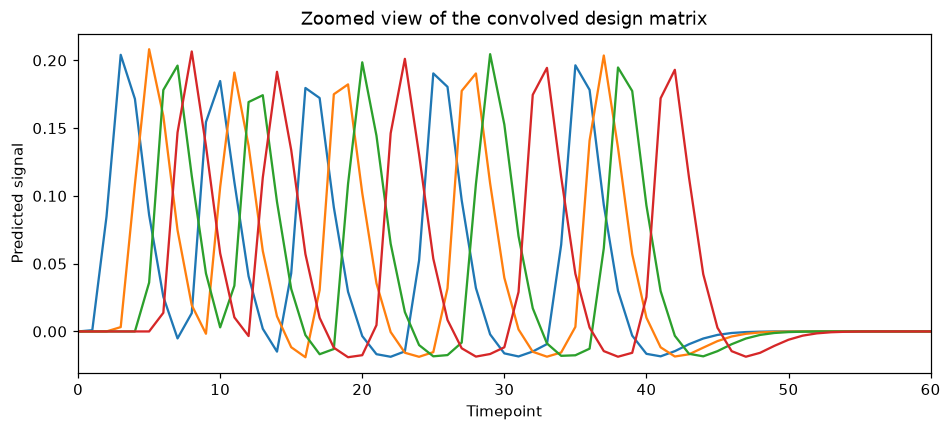

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(best_design.Xconv)
plt.xlim(0, 60)
plt.title("Zoomed view of the convolved design matrix")
plt.xlabel("Timepoint")
plt.ylabel("Predicted signal")
plt.show()


## 4. Takeaway

Use `event_transition_interval` when the timing between two events depends on the transition that produced them — and remember that it only has an effect on multi-event trials; a one-event-per-trial flat design has no within-trial gap for it to control. The pattern to remember is:

- build trials with more than one event, using `trial_templates`,
- specify transition rules with `(previous_event, current_event)`, keyed by event category,
- include a `default` rule for any within-trial transition not explicitly listed,
- keep `event_transition_interval` and `inter_trial_interval` conceptually separate: one governs gaps inside a trial, the other governs gaps between trials.
